# Análisis y Predicción de la popularidad de una canción  
__OBJETIVO__: Analizar las caracteristicas de audio de canciones en diversas plataformas con el fin de identificar estructuras que nos permitan clasificar en generos musicales y predecir su nivel de popularidad, facilitando así la comprensión de los factores que influyen en el exito musical  

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,mean_squared_error,accuracy_score,confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn import preprocessing
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA


import warnings
warnings.filterwarnings("ignore")

In [3]:
Url = 'https://raw.githubusercontent.com/Eduardo7h/Proyecto-IA/ec6f5e2c1ee0db12cefc422e1550cd1ebfca22e1/spotify-tracks-dataset.csv'

In [4]:
## Importamos el CSV
df = pd.read_csv(Url)

## Ceamos una copia del dataset para trabajar sobre ella
copi_df = df.copy()
copi_df.head()

,Unnamed: 0.1,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic



# Análisis Exploratorio de Datos



In [5]:
print('Tamaño del Dataset : ', copi_df.shape  )
print('\nNumero de Filas duplicadas: ', len(copi_df[df.duplicated()]))

Tamaño del Dataset :  (114000, 22)

Numero de Filas duplicadas:  0


In [6]:
## Eliminamos las fila de Unnamed: 0.1 y Unnamed: 0
copi_df.drop(['Unnamed: 0.1','Unnamed: 0'], axis=1, inplace=True)
copi_df.head(5)
copi_df.shape

(114000, 20)

In [7]:
'''
 Obtenemos los tipos de datos que hay en el dataset, asi como cuantos
 valores tenemos por cada columna
'''
copi_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  object 
 1   artists           113999 non-null  object 
 2   album_name        113999 non-null  object 
 3   track_name        113999 non-null  object 
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valence           11

In [8]:
'''
Con la informacion anterios se puede observar que tenemos valores faltantes
por lo que se procederan a borrar las filas que contengan valores nulos
'''
## Eliminamos las filas con mas de un valor faltante
copi_df.dropna(axis=0,inplace=True)

## Visualisamos que se hayan borrado corectamente
(copi_df.isnull()).sum(axis=0)



track_id            0
artists             0
album_name          0
track_name          0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [9]:
'''
con la informacion anterior se observo que la columna 'track_genre' es de tipo
object por lo que se ondara mas en esta columna
'''
copi_df['track_genre'].value_counts()


track_genre
acoustic       1000
afrobeat       1000
alt-rock       1000
alternative    1000
ambient        1000
               ... 
techno         1000
turkish        1000
trip-hop       1000
world-music    1000
k-pop           999
Name: count, Length: 114, dtype: int64

- Explorando la columna 'track_genre' se pudo observar que se trata de los generos musicales con los que contamos siendo 114 generos musicales

In [10]:
## Obtnemos una descripcion estadistica de los datos para
## realizar una rapida interpretacion
copi_df.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,113999.000000,1.139990e+05,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000
mean,33.238827,2.280312e+05,0.566801,0.641383,5.309126,-8.258950,0.637558,0.084652,0.314907,0.156051,0.213554,0.474066,122.147695,3.904034
std,22.304959,1.072961e+05,0.173543,0.251530,3.559999,5.029357,0.480708,0.105733,0.332522,0.309556,0.190378,0.259261,29.978290,0.432623
min,0.000000,8.586000e+03,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218500,4.000000
50%,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.597500,0.049000,0.273000,0.683000,140.071000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


A partir del análisis estadístico descriptivo, se observó que las canciones del dataset presentan siertas características, con una duración promedio de aproximadamente 3.8 minutos, niveles moderados de energía y bailabilidad, y un tempo medio cercano a 122 BPM.
Asimismo, la distribución de la variable 'popularity' sugiere un posible desbalance, ya que predominan las canciones con baja popularidad, lo cual podría afectar la capacidad del modelo para predecir con precisión ciertos valores extremos

In [11]:
df1 = ['popularity','duration_ms','danceability','energy','key','loudness'
,'mode','speechiness','acousticness','liveness','valence','tempo',
'time_signature','instrumentalness']

copi_df[df1].corr()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,liveness,valence,tempo,time_signature,instrumentalness
popularity,1.000000,-0.007129,0.035444,0.001053,-0.003847,0.050420,-0.013948,-0.044930,-0.025458,-0.005397,-0.040522,0.013212,0.031076,-0.095147
duration_ms,-0.007129,1.000000,-0.073435,0.058520,0.008123,-0.003475,-0.035581,-0.062605,-0.103770,0.010308,-0.154464,0.024356,0.018229,0.124364
danceability,0.035444,-0.073435,1.000000,0.134325,0.036470,0.259076,-0.069224,0.108625,-0.171531,-0.131620,0.477347,-0.050448,0.207219,-0.185608
energy,0.001053,0.058520,0.134325,1.000000,0.048007,0.761690,-0.078365,0.142508,-0.733908,0.184795,0.258937,0.247852,0.187127,-0.181880
key,-0.003847,0.008123,0.036470,0.048007,1.000000,0.038591,-0.135911,0.020419,-0.040942,-0.001597,0.034099,0.010914,0.015064,-0.006821
loudness,0.050420,-0.003475,0.259076,0.761690,0.038591,1.000000,-0.041768,0.060826,-0.589804,0.076897,0.279851,0.212447,0.191992,-0.433478
mode,-0.013948,-0.035581,-0.069224,-0.078365,-0.135911,-0.041768,1.000000,-0.046535,0.095568,0.014004,0.021964,0.000572,-0.024090,-0.049961
speechiness,-0.044930,-0.062605,0.108625,0.142508,0.020419,0.060826,-0.046535,1.000000,-0.002184,0.205218,0.036637,0.017274,-0.000011,-0.089617
acousticness,-0.025458,-0.103770,-0.171531,-0.733908,-0.040942,-0.589804,0.095568,-0.002184,1.000000,-0.020693,-0.107081,-0.208231,-0.176142,0.104033
liveness,-0.005397,0.010308,-0.131620,0.184795,-0.001597,0.076897,0.014004,0.205218,-0.020693,1.000000,0.019093,0.000603,-0.023649,-0.079896


Apartir de analisis de la matriz de correlación, seleccionamos como variables independientes 'danceability','speechiness', 'valence','tempo','liveness','duration_ms' y 'energy', para poder evitar asi problemas de multicolinealidad. La variable objetivo del modelo es 'popularity'

In [97]:
## Definimos las variables X, y

X = copi_df[['danceability','speechiness',
              'valence','tempo',
              'liveness','duration_ms','energy']]

y = copi_df['popularity']  # variable objetivo

In [98]:

## Dividimos en conjunto de datos en Entrenamineto y Prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
                                                    random_state=123)


In [99]:
## Creamos el modelo
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [100]:
y_pred = model.predict(X_test)

In [101]:
## Evaluamos el modelo con las metricas de erro
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test,y_pred)

print(f'Coeficientes del modelo:\n {model.coef_}')
print(f'\nIntercepto: {model.intercept_:.3f}')
print(f'\nR2 del modelo: {r2:.3f}')
print(f'\nError Cuadratico Medio MSE: {mse:.3f}')

Coeficientes del modelo:
 [ 1.07603435e+01 -1.21915029e+01 -7.41366224e+00  1.54645917e-02
  2.10426169e+00 -3.85999753e-06  1.27427281e+00]

Intercepto: 29.374

R2 del modelo: 0.009

Error Cuadratico Medio MSE: 493.439


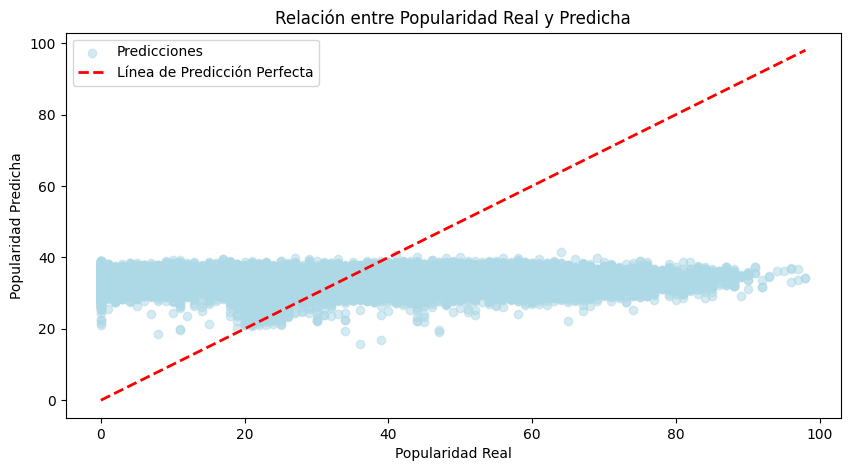

In [18]:
## Visualizacion de la relacion entre valores reales y predichos
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred, c='lightblue', alpha=0.5, label='Predicciones')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], c='red', linestyle='--', linewidth=2, label='Línea de Predicción Perfecta')
plt.xlabel('Popularidad Real')
plt.ylabel('Popularidad Predicha')
plt.title('Relación entre Popularidad Real y Predicha')
plt.legend()
plt.show()

El modelo de regresión lineal multiple obtuvo un coeficiente de determinación (R2) cercano a cero, lo que indica una baja capacidad explicativa. Por lo que podemos concluir que las variables utilizadas, basadas en caracteristicas acusticas, no son suficientes para predecir la popularidad de una canción, evidenciando la influencia de otros factores externos no considerados en el modelo

# Aplicando un segundo modelo (Random Forest)

In [19]:
## Creamos el bosque aleatorio
bosque = RandomForestRegressor(n_estimators=100, criterion='squared_error', # estimador -> num de arboles
                                max_features='sqrt',bootstrap=True,
                                max_samples=2/3,oob_score=True)  ## oob_score metrica para bosques

## Realizamos el entrenamiento
bosque.fit(X_train,y_train)

RandomForestRegressor(max_features='sqrt', max_samples=0.6666666666666666,
                      oob_score=True)

In [20]:
y_pred_randomf = bosque.predict(X_test)

In [21]:
## Metricas para evaluacion del modelo
r2_randomf = r2_score(y_test, y_pred_randomf)
mse_randomf = mean_squared_error(y_test, y_pred_randomf)

print(f'OOB Score del modelo Random Forest:{bosque.oob_score_:.2f}')
print(f'R2 del modelo Random Forest: {r2_randomf:.2f}')
print(f'Error Cuadratico Medio (MSE) del modelo Random Forest: {mse_randomf:.2f}')

OOB Score del modelo Random Forest:0.46
R2 del modelo Random Forest: 0.47
Error Cuadratico Medio (MSE) del modelo Random Forest: 264.16


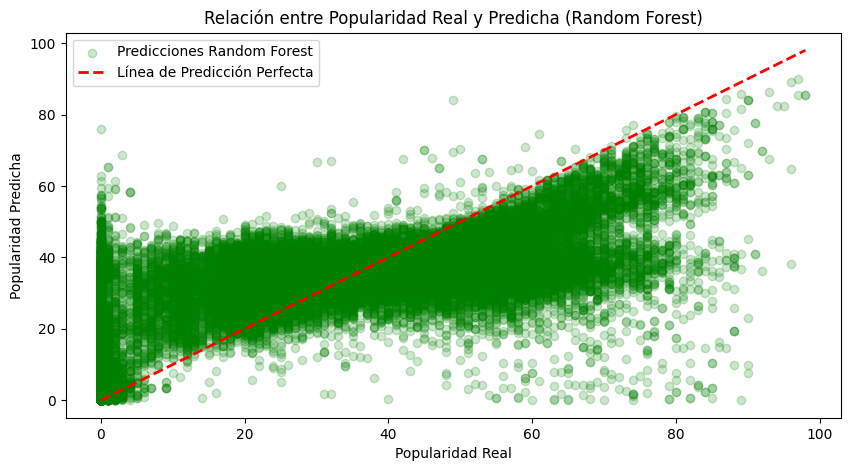

In [22]:
## Visualizacion de la relacion entre valores reales y predichos
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred_randomf, c='green', alpha=0.2, label='Predicciones Random Forest')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], c='red', linestyle='--', linewidth=2, label='Línea de Predicción Perfecta')
plt.xlabel('Popularidad Real')
plt.ylabel('Popularidad Predicha')
plt.title('Relación entre Popularidad Real y Predicha (Random Forest)')
plt.legend()
plt.show()

El modelo de regresión lineal presentó un bajo desempeño, con un R2 cercano a cero, indicando que no lograba capturar la relación entre las variables.
Sin embargo, al utilizar un modelo de Random Forest, el desempeño mejoró considerablemente (R2 = 0.47), lo que evidencia que la presencia de relaciones es no lineal entre las características de audio y la popularidad de las canciones.

como una validacion adicional se utilizó el oob_score el cual es una estimación adicional del desempeño del modelo, aprovechando el muestreo interno del algoritmo Random Forest, se obtuvo aproximadamente 0.46 lo cual es un valor muy cercano al valor de R2 obtenido en el conjunto de prueba. Esto nos indica que el modelo tinen una buena capacidad de generalizacion  

In [23]:
bosque.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': 0.6666666666666666,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': True,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [29]:
## Tratamos de mejorar el modelo implementando GridSearchCV

## definimos un diccionario con los parametros a explorar
param_gid ={'criterion':('gini','entroppy','squared_error'),
            'n_estimators': (50,100,150,200),
            'max_samples' : (1/3,2/3),
            'max_features': ('sqrt','log2')
}

## Definimos el Gridserach
rejilla = GridSearchCV(bosque,
                       param_gid,
                       scoring='r2')
## Construccion de los modelos con los parametros
rejilla.fit(X_train,y_train)


GridSearchCV(estimator=RandomForestRegressor(max_features='sqrt',
                                             max_samples=0.6666666666666666,
                                             oob_score=True),
             param_grid={'criterion': ('gini', 'entroppy', 'squared_error'),
                         'max_features': ('sqrt', 'log2'),
                         'max_samples': (0.3333333333333333,
                                         0.6666666666666666),
                         'n_estimators': (50, 100, 150, 200)},
             scoring='r2')

In [43]:
## Informacion de la busqueda en Grid
rejilla.cv_results_.keys()

#Grid de Parametros Explorados
rejilla.cv_results_['params']

## Resultados de la Busqueda en Grid
print('\n',rejilla.cv_results_['rank_test_score'])
print('\nEvaluacion de R2 de los modelos \n',rejilla.cv_results_['mean_test_score'])
print(f'\nMejor valor de R2 -> {rejilla.best_score_:.4f}')
print(f'\nParametros del mejor modelo en funcion de R2 \n{rejilla.best_params_}')



 [17 17 17 17 17 17 17 17 17 17 17 17 17 17 17 17 17 17 17 17 17 17 17 17
 17 17 17 17 17 17 17 17 16 14 10 11  8  6  3  1 15 13 12  9  7  5  4  2]

Evaluacion de R2 de los modelos 
 [       nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan 0.35524071 0.36242193 0.36721716 0.36705691
 0.4193541  0.42707659 0.43013873 0.43197822 0.35529217 0.3630002
 0.36638698 0.3679325  0.42071175 0.42732125 0.42978509 0.43158856]

Mejor valor de R2 -> 0.4320

Parametros del mejor modelo en funcion de R2 
{'criterion': 'squared_error', 'max_features': 'sqrt', 'max_samples': 0.6666666666666666, 'n_estimators': 200}


In [38]:
y_Grid = bosque.predict(X_test)
print(y_Grid)
print(f'Coeficiente de determinnacion: {bosque.score(X_test,y_test):.4}')
print(f'oob score: {bosque.oob_score_:.4}')

[32.19       37.277      14.70898413 ... 38.4        40.07833333
 40.87      ]
Coeficiente de determinnacion: 0.4697
oob score: 0.4626


la optimización de hiperametros mediante el uso de GridSearchCV no produjo una mejora significativa en el desempeño del modelo, por lo que podemos concluir que el modelo inicial ya se encotraba cercano al mejor rendimiento con las variables que tenemos disponible.

Esto implica que la limitacion principal no radica en el modelo, sino talvez en la informacion que tenemos disponible

# Clasificacion
Objetivo: poder clasificar canciones por genero apartir de sus caracteristicas

In [12]:
## Definimos las variables X, y

X_knn = copi_df[['danceability','speechiness',
              'valence','tempo',
              'liveness','duration_ms','energy']]

In [25]:
'''como la var track_genre es una variable categorica buscamos transfomar
a un formato numerico para poder entrenar el modelo'''

le = LabelEncoder()
y_knn = le.fit_transform(copi_df['track_genre'])

copi_df['track_genre']


0            acoustic
1            acoustic
2            acoustic
3            acoustic
4            acoustic
             ...     
113995    world-music
113996    world-music
113997    world-music
113998    world-music
113999    world-music
Name: track_genre, Length: 113999, dtype: object

In [26]:
le.classes_

array(['acoustic', 'afrobeat', 'alt-rock', 'alternative', 'ambient',
       'anime', 'black-metal', 'bluegrass', 'blues', 'brazil',
       'breakbeat', 'british', 'cantopop', 'chicago-house', 'children',
       'chill', 'classical', 'club', 'comedy', 'country', 'dance',
       'dancehall', 'death-metal', 'deep-house', 'detroit-techno',
       'disco', 'disney', 'drum-and-bass', 'dub', 'dubstep', 'edm',
       'electro', 'electronic', 'emo', 'folk', 'forro', 'french', 'funk',
       'garage', 'german', 'gospel', 'goth', 'grindcore', 'groove',
       'grunge', 'guitar', 'happy', 'hard-rock', 'hardcore', 'hardstyle',
       'heavy-metal', 'hip-hop', 'honky-tonk', 'house', 'idm', 'indian',
       'indie', 'indie-pop', 'industrial', 'iranian', 'j-dance', 'j-idol',
       'j-pop', 'j-rock', 'jazz', 'k-pop', 'kids', 'latin', 'latino',
       'malay', 'mandopop', 'metal', 'metalcore', 'minimal-techno', 'mpb',
       'new-age', 'opera', 'pagode', 'party', 'piano', 'pop', 'pop-film',
       'pow

In [16]:
## Escalar los datos
escalador = preprocessing.MinMaxScaler() ## Escala los datos en un rango de 0-1
X_knn = escalador.fit_transform(X_knn)



In [17]:

## Dividimos en conjunto de datos en Entrenamineto y Prueba ya escalados
X_train, X_test, y_train, y_test = train_test_split(X_knn, y_knn, test_size=0.3,
                                                    random_state=123)

print('Tamaño del conjunto de Entrenamiento-> ', X_train.shape)
print('Tamaño del conjunto de Prueba-> ',X_test.shape)

Tamaño del conjunto de Entrenamiento->  (79799, 7)
Tamaño del conjunto de Prueba->  (34200, 7)


In [18]:
## Creamos el modelo de KNN
Clasificador =  KNeighborsClassifier(n_neighbors=50 )
Clasificador.fit(X_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",50
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [19]:
##Predicciones
y_pred = Clasificador.predict(X_test)

## Calculamos el accuracy del modelo
accuracy = accuracy_score(y_test, y_pred)
print('Accuracy ->',accuracy)


Accuracy -> 0.1317543859649123


In [20]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.05      0.08      0.06       293
           1       0.03      0.03      0.03       283
           2       0.05      0.08      0.06       277
           3       0.06      0.05      0.06       302
           4       0.12      0.11      0.11       335
           5       0.04      0.02      0.03       306
           6       0.28      0.32      0.30       305
           7       0.11      0.18      0.14       314
           8       0.06      0.04      0.05       326
           9       0.02      0.01      0.01       323
          10       0.09      0.06      0.07       294
          11       0.08      0.04      0.05       308
          12       0.06      0.14      0.08       297
          13       0.14      0.28      0.19       290
          14       0.32      0.23      0.27       325
          15       0.08      0.06      0.07       292
          16       0.30      0.22      0.25       329
          17       0.11    

Los resultado no fueron los esperados, ya que se obtuvo un bajo accuracy, así como métricas de precision, recall, f1-score y support igualmete bajas. Es probable que se deba al gran numero de generos musicales y al alto parecido entre ellas.

Por lo que se planteo reducir tanto la cantidad de generos musicales como el número de variables utilizadas.  

In [15]:
## Reducimos X
X_knn_redu = copi_df[['danceability','energy','valence','tempo']]

# Reducimos el numero de generos a 10
top_genres = copi_df['track_genre'].value_counts().head(10).index
copi_df = copi_df[copi_df['track_genre'].isin(top_genres)]

In [16]:
le = LabelEncoder()
y_knn_redu = le.fit_transform(copi_df['track_genre'])

copi_df['track_genre']

,track_genre
0,acoustic
1,acoustic
2,acoustic
3,acoustic
4,acoustic
...,...
9995,brazil
9996,brazil
9997,brazil
9998,brazil


In [24]:
le.classes_

array(['acoustic', 'afrobeat', 'alt-rock', 'alternative', 'ambient',
       'anime', 'black-metal', 'bluegrass', 'blues', 'brazil',
       'breakbeat', 'british', 'cantopop', 'chicago-house', 'children',
       'chill', 'classical', 'club', 'comedy', 'country', 'dance',
       'dancehall', 'death-metal', 'deep-house', 'detroit-techno',
       'disco', 'disney', 'drum-and-bass', 'dub', 'dubstep', 'edm',
       'electro', 'electronic', 'emo', 'folk', 'forro', 'french', 'funk',
       'garage', 'german', 'gospel', 'goth', 'grindcore', 'groove',
       'grunge', 'guitar', 'happy', 'hard-rock', 'hardcore', 'hardstyle',
       'heavy-metal', 'hip-hop', 'honky-tonk', 'house', 'idm', 'indian',
       'indie', 'indie-pop', 'industrial', 'iranian', 'j-dance', 'j-idol',
       'j-pop', 'j-rock', 'jazz', 'k-pop', 'kids', 'latin', 'latino',
       'malay', 'mandopop', 'metal', 'metalcore', 'minimal-techno', 'mpb',
       'new-age', 'opera', 'pagode', 'party', 'piano', 'pop', 'pop-film',
       'pow

In [18]:
## Escalar los datos
escalador = preprocessing.MinMaxScaler() ## Escala los datos en un rango de 0-1
X_knn_redu = escalador.fit_transform(X_knn_redu)


array([[0.68629442, 0.461     , 0.71859296, 0.36124534],
       [0.42639594, 0.166     , 0.26834171, 0.31839735],
       [0.44467005, 0.359     , 0.12060302, 0.31364331],
       ...,
       [0.63857868, 0.329     , 0.74673367, 0.54393274],
       [0.59593909, 0.506     , 0.41507538, 0.55865095],
       [0.53401015, 0.487     , 0.71155779, 0.32541952]])

In [77]:

## Dividimos en conjunto de datos en Entrenamineto y Prueba ya escalados
X_train, X_test, y_train, y_test = train_test_split(X_knn_redu, y_knn_redu, test_size=0.3,
                                                    random_state=123)

print('Tamaño del conjunto de Entrenamiento-> ', X_train.shape)
print('Tamaño del conjunto de Prueba-> ',X_test.shape)

Tamaño del conjunto de Entrenamiento->  (7000, 4)
Tamaño del conjunto de Prueba->  (3000, 4)


In [ ]:
## Creamos el modelo de KNN
Clasificador =  KNeighborsClassifier(n_neighbors=50 ) ## PCA desacoplar 
Clasificador.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=50)

In [79]:
##Predicciones del conjunto reducido
y_pred = Clasificador.predict(X_test)

## Calculamos el accuracy del modelo
accuracy = accuracy_score(y_test, y_pred)
print('Accuracy ->',accuracy)

Accuracy -> 0.37966666666666665


In [80]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.31      0.33      0.32       301
           1       0.32      0.43      0.37       307
           2       0.24      0.25      0.25       322
           3       0.21      0.13      0.16       281
           4       0.54      0.72      0.62       274
           5       0.30      0.18      0.22       328
           6       0.67      0.80      0.73       291
           7       0.41      0.54      0.47       310
           8       0.35      0.22      0.27       305
           9       0.27      0.24      0.25       281

    accuracy                           0.38      3000
   macro avg       0.36      0.38      0.37      3000
weighted avg       0.36      0.38      0.36      3000



Al reducir el numero de generos, el moelo de KNN mejoro significativamente su desempeño, alcanzado un accuracy del 38%. Esto coincide con nuestra conclusión previade que un gran número de categorias genera traslape de características acusticas
por lo tanto, algunos generos son mas distinguibles que otros, lo que se suguiere que algunas categorias musicales presentan caracteristicas mas definidas que otras


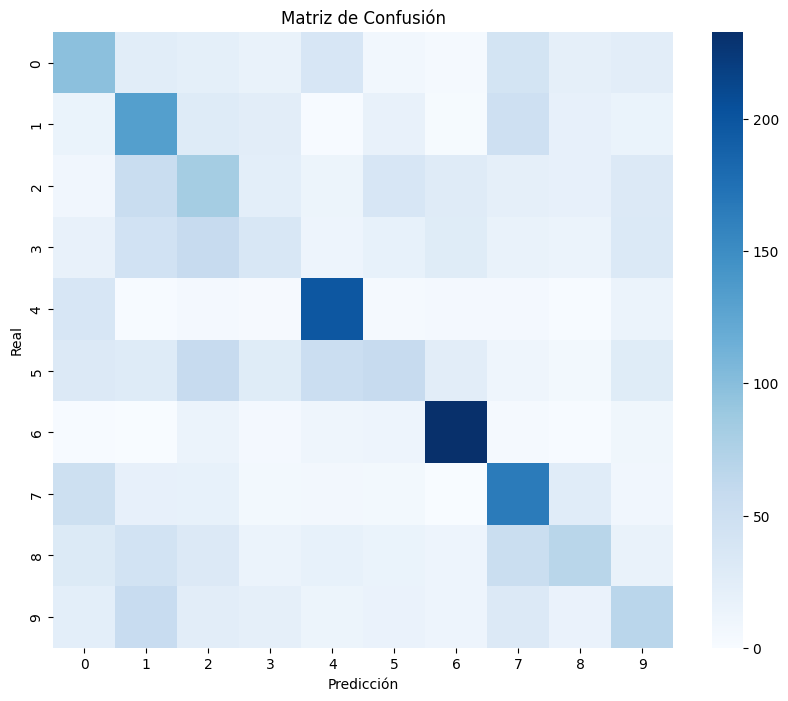

In [81]:
## Matriz de confucion
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=False, cmap='Blues')
plt.title("Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

In [88]:
## Nombre de los generos usados
le.classes_

array(['acoustic', 'afrobeat', 'alt-rock', 'alternative', 'ambient',
       'anime', 'black-metal', 'bluegrass', 'blues', 'brazil'],
      dtype=object)

Con ayuda de la matriz de confusión, se observa que el modelo logra identificar ciertos generos con caracteristicas bien definidas, mientras que otros presentan un alto grado de traslape, lo que genera confucion en la clasificacion.
Cabe mencionar que los errores no son aleatorias, sino que ocurren entre generos con carcateristicas acusticas similares

# Agrupamiento
objetivo : Poder Agrupar canciones sin etiquetas


In [19]:
## Seleccionamos solo las variables mas adecuadas

X_clus = copi_df[['danceability','energy','valence','tempo']]

## Escalamos los datos
escalador_clus = MinMaxScaler()
X_scaled = escalador_clus.fit_transform(X_clus)


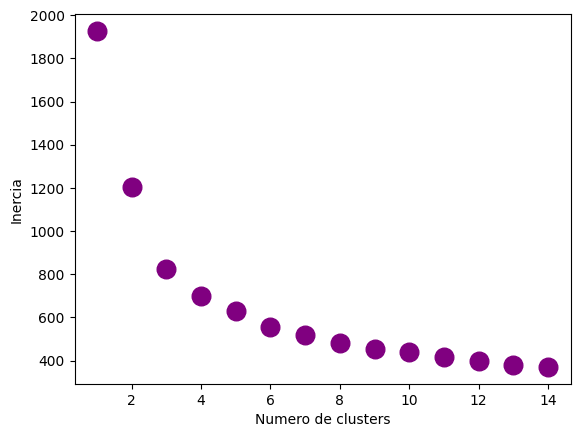

In [36]:
## Para determinar el numero de cluster usaremos el metodo del codo
inercias = []

for K in range(1,15):
  kmeans = KMeans(n_clusters=K).fit(X_scaled)
  inercias.append(kmeans.inertia_)

#Greficamos
#plt.figure(figsize=(60,30))
plt.scatter(range(1,15), inercias , marker='o', s=180, color = 'purple')
plt.xlabel('Numero de clusters')
plt.ylabel('Inercia')
plt.show()

In [41]:
## Una vez determinado el nmero de clusters podemos crear el modelo
modelo_Kmeans = KMeans(n_clusters=3).fit(X_scaled)

## Creamos una nueva columna en X_clus donde agregamos a que
# Cluster pertenece

X_clus['Cluster'] = modelo_Kmeans.labels_

## Imprimimos las coordenandas de los centros y su inercia (que tan lejos estan los valores del centro )
print('Ubicacion de los Centros \n',modelo_Kmeans.cluster_centers_)
print('Inercia del modelo -> ', modelo_Kmeans.inertia_ )




Ubicacion de los Centros 
 [[0.64258853 0.70385092 0.7251597  0.4998266 ]
 [0.47844113 0.29222091 0.25428896 0.46480571]
 [0.40685752 0.83150929 0.27870811 0.53570218]]
Inercia del modelo ->  825.4763629255679


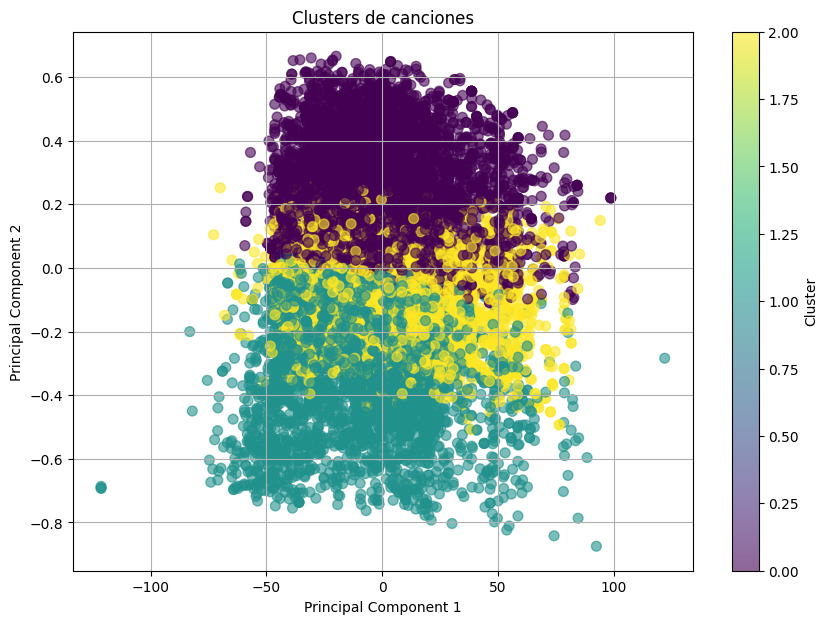

In [ ]:
## Como tenemos 4 variables es dificil visializar los clusters por lo que implementaremos PCA para reducir las dimensiones
##  a 2 para graficar los clusters 

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_clus.drop('Cluster', axis=1))

plt.figure(figsize=(10, 7))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=X_clus['Cluster'], cmap='viridis', s=50, alpha=0.6)
plt.colorbar(label='Cluster')
plt.title("Clusters de canciones")
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

## Probar con diferentes graficas cambiondo ejes 
## Centroides caracteristicas originales
## Parte interpretaiva 


La implementacion de K-means nos permitio identificar disitintos grupos de canciones, observandose patrones asociados a niveles de energia e intencidad. No obstante, se aprecia cierto traslape entre grupos, lo que refleja la naturaleza continua de las caracteristicas musicales
